# Tuning the pivoting tolerances of `linprog_simplex`: analysis of the grid runs

`tuning_LP_solver.py` solves each of 54 Netlib test problems for every combination of
the `PivOptions` tolerances `(fea_tol, tol_piv, tol_ratio_diff)` in a cartesian grid, with
`max_iter=10_000`. Two runs have been completed:

| file | `fea_tol` | `tol_piv` | `tol_ratio_diff` | combinations |
|---|---|---|---|---|
| `results.csv` | 1e-4, ..., 1e-8 | 1e-8, ..., 1e-12 | 1e-11, ..., 1e-15 | 125 |
| `results_complement.csv` | 1e-4, ..., 1e-8 | 1e-5, 1e-6, 1e-7 | 1e-11, ..., 1e-15 | 75 |

Each file has one row per (parameter combination, problem) with the columns
`param_idx, fea_tol, tol_piv, tol_ratio_diff, problem, fun, success, status, num_iter, exec_time`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_main = pd.read_csv('results.csv')             # tol_piv in {1e-8, ..., 1e-12}
df_comp = pd.read_csv('results_complement.csv')  # tol_piv in {1e-5, 1e-6, 1e-7}

# Stack the complementary run on top of the first one, as in the original
# analysis, and index the parameter combinations 0, ..., 199 in that order.
df_main['param_idx'] += df_comp['param_idx'].max() + 1
df = pd.concat([df_comp, df_main], ignore_index=True)

param_set = (df[['param_idx', 'fea_tol', 'tol_piv', 'tol_ratio_diff']]
             .drop_duplicates().set_index('param_idx'))
problems = list(dict.fromkeys(df['problem']))  # in the order of the runs
print(len(param_set), 'parameter combinations x', len(problems), 'problems')

200 parameter combinations x 54 problems


In [3]:
def wide(col):
    """Table with parameter combinations as rows and problems as columns."""
    return df.pivot(index='param_idx', columns='problem', values=col)[problems]

df_res_success = wide('success').astype(int)
df_res_fun = wide('fun')
df_num_iter = wide('num_iter')
df_runtime = wide('exec_time')

## Results analysis

Text(0.5, 0, 'Problem index')

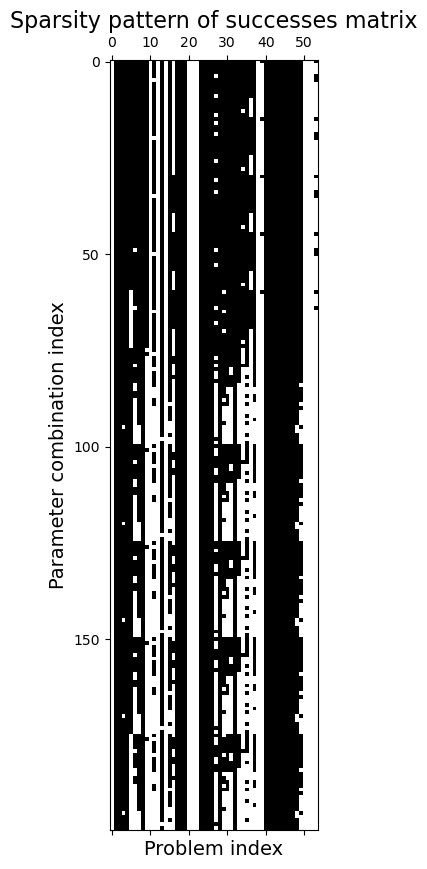

In [4]:
plt.figure(figsize=(10, 10))
plt.spy(df_res_success.values, aspect=None);
plt.title('Sparsity pattern of successes matrix', fontsize=16);
plt.ylabel('Parameter combination index', fontsize=14)
plt.xlabel('Problem index', fontsize=14)

Note: within each run the parameter combinations are in cartesian order with `tol_ratio_diff`
varying fastest, then `tol_piv`, then `fea_tol`. In the plots below the red dashed lines separate
blocks of 5 combinations (one value of `tol_piv`) and the black ones blocks of 25 (one value of
`fea_tol`); rows 0-74 are the complementary run, rows 75-199 the first run.

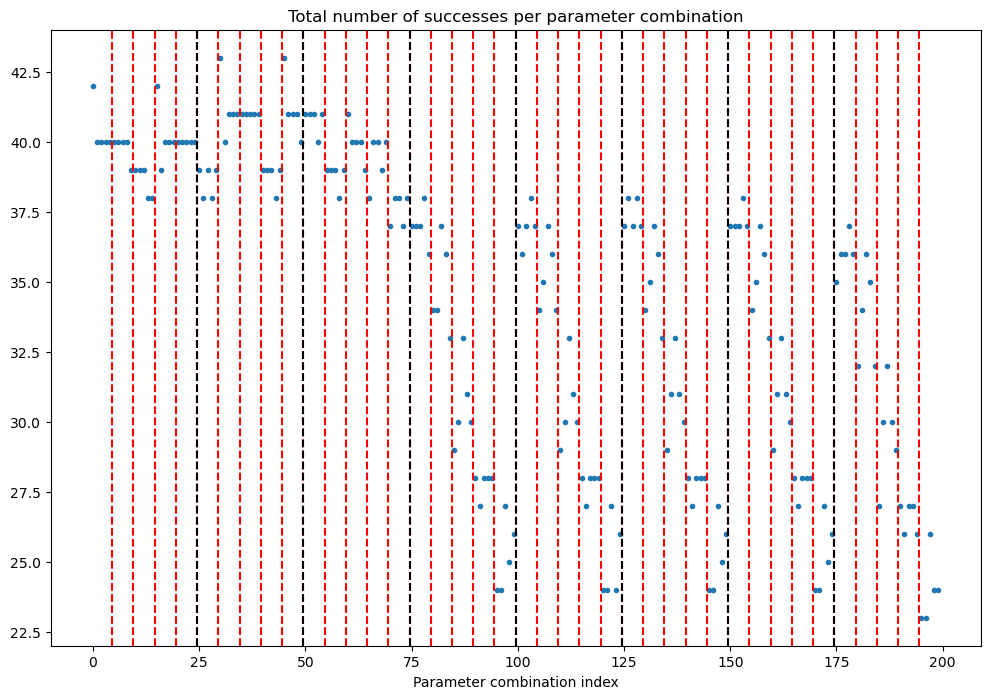

In [5]:
def separators(n):
    for x_val in np.arange(4, n - 5, 5) + 0.5:
        plt.axvline(x_val, ls='--', color='red')
    for x_val in np.arange(24, n - 25, 25) + 0.5:
        plt.axvline(x_val, ls='--', color='black')

plt.figure(figsize=(12, 8))
plt.plot(df_res_success.sum(axis=1), 'o', markersize=3.);
plt.xlabel('Parameter combination index');
plt.title('Total number of successes per parameter combination');
separators(len(param_set))

In [6]:
# Set of maximizers
num_success = df_res_success.sum(axis=1)
argmax_set = num_success[num_success == num_success.max()].index
param_set.loc[argmax_set].assign(num_success=num_success.max())

,fea_tol,tol_piv,tol_ratio_diff,num_success
param_idx,,,,
30,1.000000e-06,0.00001,1.000000e-11,43
45,1.000000e-07,0.00001,1.000000e-11,43


## Observations

- There are multiple maximimzers.
- Some parameter combinations seem to perform much better than others

### Alternative success criterion

`success` is what `linprog_simplex` reports. Alternatively, count a solve as a success when the
value found is close to the Netlib optimal value (negated, since the problems are formulated as
minimization problems).

In [7]:
data_dir = 'linprog_benchmark_files'
funs = np.array([-np.load(os.path.join(data_dir, name + '.npz'))['obj']
                 for name in problems])

In [8]:
TOL = 1e-1

abs_diff = np.abs(df_res_fun - funs)
rel_diff = np.abs(df_res_fun / funs) - 1

In [9]:
df_res_success_alt = ((abs_diff < TOL) | (rel_diff < TOL)).astype(int)

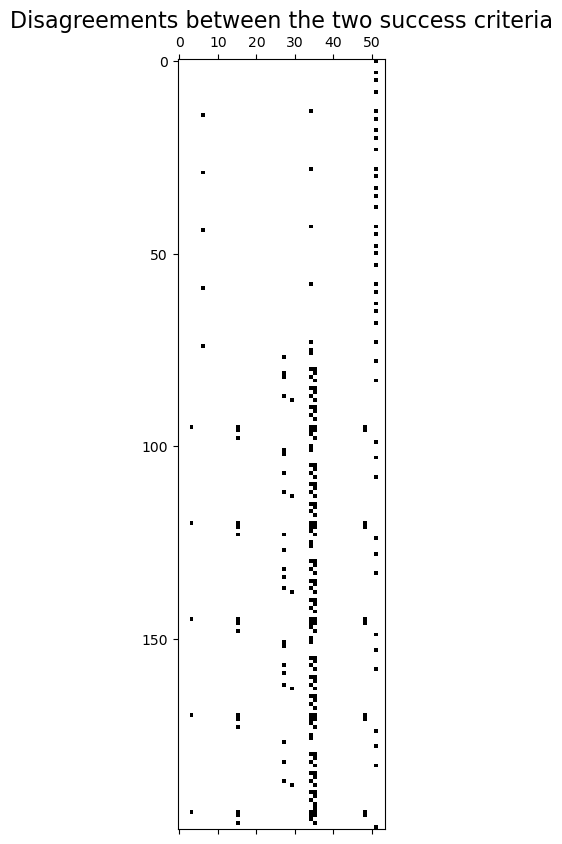

In [10]:
plt.figure(figsize=(10, 10))
plt.spy(np.abs(df_res_success - df_res_success_alt))
plt.title('Disagreements between the two success criteria', fontsize=16);

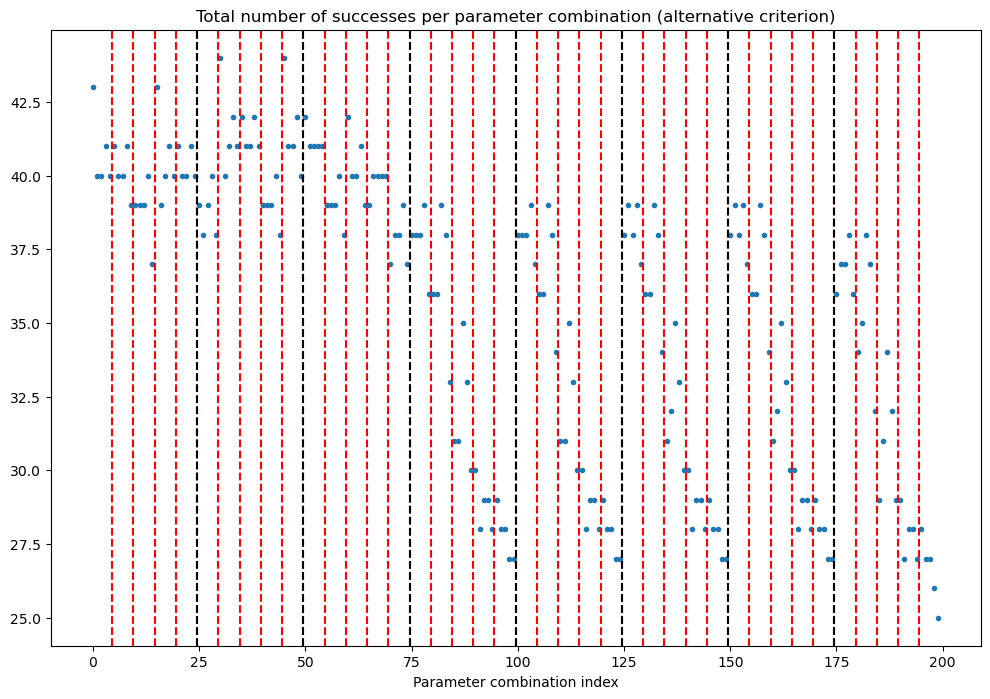

In [11]:
plt.figure(figsize=(12, 8))
plt.plot(df_res_success_alt.sum(axis=1), 'o', markersize=3.);
plt.xlabel('Parameter combination index');
plt.title('Total number of successes per parameter combination (alternative criterion)')
separators(len(param_set))

In [12]:
# Set of maximizers
num_success_alt = df_res_success_alt.sum(axis=1)
argmax_set_alt = num_success_alt[num_success_alt == num_success_alt.max()].index
param_set.loc[argmax_set_alt].assign(num_success_alt=num_success_alt.max())

,fea_tol,tol_piv,tol_ratio_diff,num_success_alt
param_idx,,,,
30,1.000000e-06,0.00001,1.000000e-11,44
45,1.000000e-07,0.00001,1.000000e-11,44


In [13]:
# Check if argmax_set is a subset of argmax_set_alt
argmax_set.isin(argmax_set_alt).all()

np.True_

## Maximum Number of Iterations Reached

In [14]:
max_itr = 10_000

df_max_itr_reached = df_num_iter == max_itr
df_failure_not_max_itr = ~df_res_success.astype(bool) & ~df_max_itr_reached

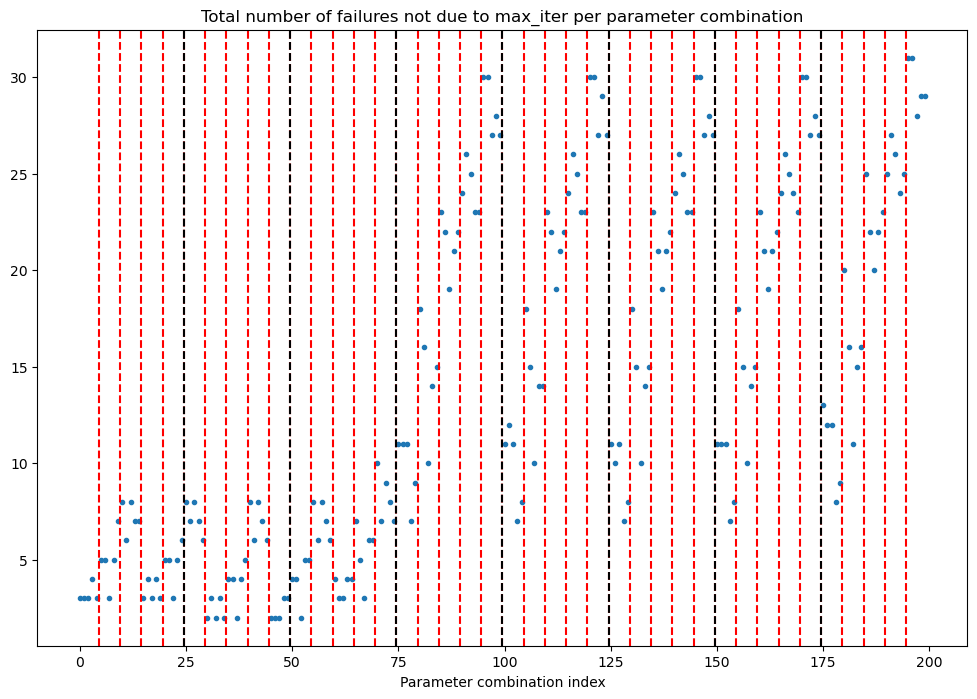

In [15]:
plt.figure(figsize=(12, 8))
plt.plot(df_failure_not_max_itr.sum(axis=1), 'o', markersize=3.);
plt.xlabel('Parameter combination index');
plt.title('Total number of failures not due to max_iter per parameter combination')
separators(len(param_set))

In [16]:
# Set of minimizers
num_failure = df_failure_not_max_itr.sum(axis=1)
argmin_set = num_failure[num_failure == num_failure.min()].index
param_set.loc[argmin_set].assign(num_failure=num_failure.min())

,fea_tol,tol_piv,tol_ratio_diff,num_failure
param_idx,,,,
30,1.000000e-06,0.000010,1.000000e-11,2
32,1.000000e-06,0.000010,1.000000e-13,2
34,1.000000e-06,0.000010,1.000000e-15,2
37,1.000000e-06,0.000001,1.000000e-13,2
45,1.000000e-07,0.000010,1.000000e-11,2
46,1.000000e-07,0.000010,1.000000e-12,2
47,1.000000e-07,0.000010,1.000000e-13,2
52,1.000000e-07,0.000001,1.000000e-13,2


## Runtime Analysis

In [17]:
# Problems with the largest average runtime across parameter combinations, in seconds
df_runtime.mean(axis=0).sort_values(ascending=False).head(8)

problem
QAP15       783.232766
STOCFOR3    354.733801
QAP12       199.911776
MAROS-R7     56.795238
BNL2         43.375180
D2Q06C       43.229372
TRUSS        42.737469
DEGEN3       37.780992
dtype: float64

In [18]:
# Problems with the largest runtime standard deviation across parameter combinations, in seconds
df_runtime.std(axis=0).sort_values(ascending=False).head(8)

problem
QAP15       556.145025
QAP12       154.495634
D2Q06C       43.800949
STOCFOR3     39.006993
BNL2         28.031598
TRUSS        24.718894
SCTAP3       14.304036
WOODW        12.793035
dtype: float64

## Observations

- A handful of problems dominate the total runtime, and the same problems have large standard
  deviations across parameter combinations (see the two tables above).

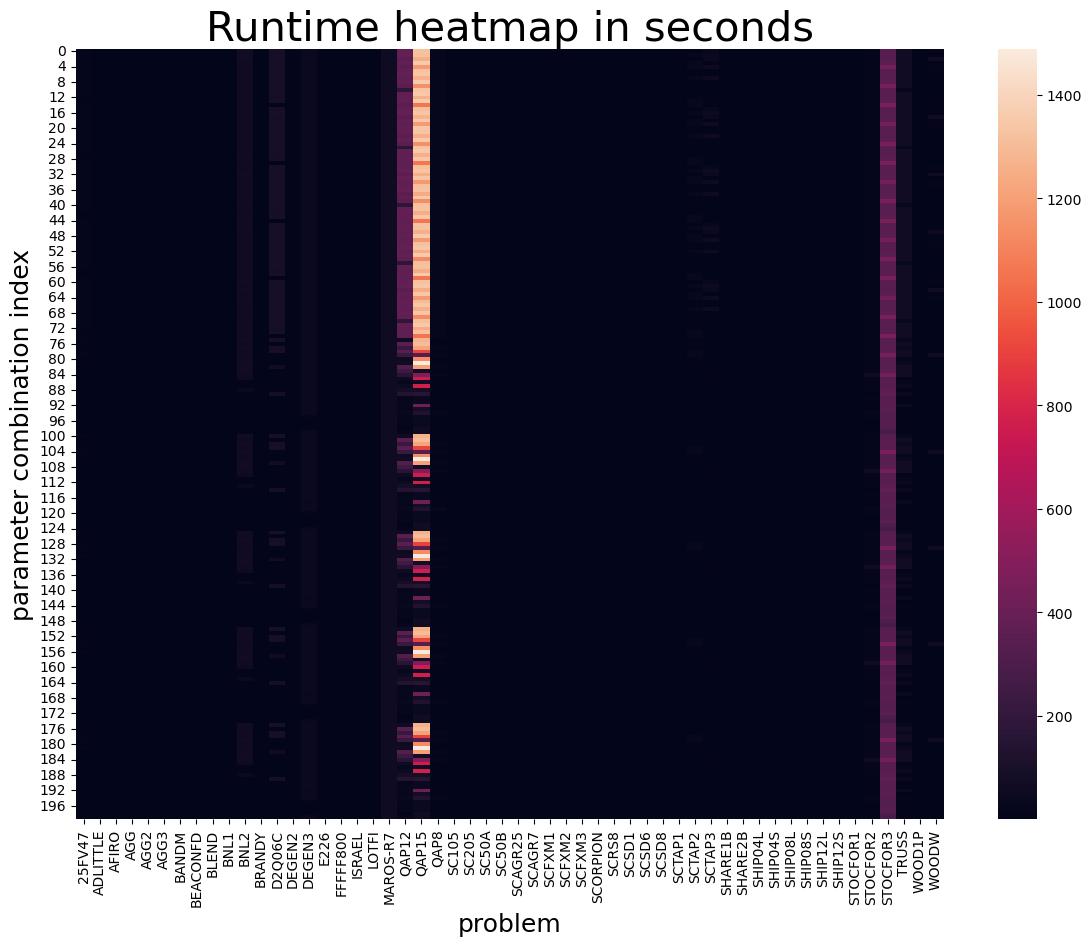

In [19]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_runtime)
plt.title('Runtime heatmap in seconds', fontsize=30)
plt.xlabel('problem', fontsize=18);
plt.ylabel('parameter combination index', fontsize=18);

In [20]:
# Average runtime of the maximizers (alternative criterion)
df_runtime.loc[argmax_set_alt].mean(axis=1)

param_idx
30    45.018283
45    45.501234
dtype: float64

## Best combination: minimize average runtime conditional on maximizing the number of successes

In [21]:
best = df_runtime.loc[argmax_set_alt].mean(axis=1).idxmin()
param_set.loc[best]

fea_tol           1.000000e-06
tol_piv           1.000000e-05
tol_ratio_diff    1.000000e-11
Name: 30, dtype: float64

Note that the best `tol_piv` found lies on the boundary of the grid, which is why
`tuning_LP_solver.py` now specifies a wider grid (not run yet).

For comparison, the current defaults of `quantecon.optimize.linprog_simplex`:

In [22]:
from quantecon.optimize.linprog_simplex import FEA_TOL, TOL_PIV, TOL_RATIO_DIFF

defaults = (FEA_TOL, TOL_PIV, TOL_RATIO_DIFF)
idx_default = param_set.index[np.isclose(param_set.values, defaults).all(axis=1)]
pd.DataFrame({'num_success': num_success, 'num_success_alt': num_success_alt,
              'mean_runtime': df_runtime.mean(axis=1)}).loc[idx_default].assign(
    fea_tol=FEA_TOL, tol_piv=TOL_PIV, tol_ratio_diff=TOL_RATIO_DIFF)

,num_success,num_success_alt,mean_runtime,fea_tol,tol_piv,tol_ratio_diff
param_idx,,,,,,
40,39,39,40.462309,0.000001,1.000000e-07,1.000000e-13
41,39,39,44.967446,0.000001,1.000000e-07,1.000000e-13
42,39,39,43.109808,0.000001,1.000000e-07,1.000000e-13
43,38,40,45.676972,0.000001,1.000000e-07,1.000000e-13
44,39,38,40.808099,0.000001,1.000000e-07,1.000000e-13
